In [2]:
# Step: Import required libraries and dependenciesimport tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10 as cf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


In [3]:
# Step: Load dataset into training and test/validation sets(x_train, y_train), (x_test, y_test) = cf.load_data()

In [4]:
# Step: Inspect data shapes and dimensionsprint(x_train.shape)
print(y_train.shape)
print(y_test.shape)
print(y_test.shape)


(50000, 32, 32, 3)
(50000, 1)
(10000, 1)
(10000, 1)


In [5]:
# Step: Normalize pixel values to the [0, 1] rangex_train = x_train/255.0
x_test = x_test/255.0

In [6]:
# Step: Convert labels to one-hot encoded vectorsy_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
# Step: Build the neural network architectureinput_shape = (32,32,3)
num_classes = 10
alexnet_model = models.Sequential()

# Layer 1: Conv Layer
alexnet_model.add(Conv2D(96,(11,11), strides = 4, padding = 'same', input_shape = input_shape))
alexnet_model.add(layers.BatchNormalization()) # regularization must be before activation functoion
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(MaxPooling2D(pool_size=(2, 2), strides=(1,1)))

#layer 2: Conv layer
alexnet_model.add(Conv2D(256, (5, 5), padding='same'))
alexnet_model.add(layers.BatchNormalization())
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(MaxPooling2D(pool_size=(2, 2), strides=(1,1)))

# Layer 3 : Conv Layer
alexnet_model.add(Conv2D((384), (3,3), padding="same"))

# Layer 4 : Conv Layer
alexnet_model.add(Conv2D((384), (3,3), padding="same"))

# Layer 5 : Conv Layer
alexnet_model.add(Conv2D(256, (3, 3), padding='same'))
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(MaxPooling2D(pool_size=(2, 2), strides=(1,1)))

# Flatten the data for Fully Connected Layers
alexnet_model.add(Flatten())

# Layer 6 : Fully Connected Layer
alexnet_model.add(Dense(4096))
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(layers.Dropout(0.5))

# Layer 7 : Fully Connected Layer
alexnet_model.add(Dense(4096))
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(layers.Dropout(0.5))

# Layer 8 : Fully Connected Layer
alexnet_model.add(Dense(num_classes))
alexnet_model.add(layers.Activation('softmax'))



In [11]:
# Step: Build the neural network architecturealexnet_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

In [9]:
# Step: Build the neural network architecturemodel_history = alexnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 8, 8, 96)          34944     
                                                                 
 batch_normalization (Batch  (None, 8, 8, 96)          384       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 8, 8, 96)          0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 7, 7, 96)          0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 256)         614656    
                                                                 
 batch_normalization_1 (Bat  (None, 7, 7, 256)         1

In [10]:
# Step: Build the neural network architecturetf.keras.utils.plot_model(alexnet_model, show_layer_names = True, show_shapes = True, show_dtype = False)

AttributeError: module 'pydot' has no attribute 'InvocationException'

In [12]:
# Create data augmentation generator
datagen = ImageDataGenerator(
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

In [13]:
# Step: Train the model and capture training historydatagen.fit(x_train)

In [14]:
# Step: Build the neural network architecturehistory = alexnet_model.fit(datagen.flow(x_train, y_train, batch_size = 512),epochs = 2,
                            validation_data = (x_test, y_test),
                            verbose = 1)

Epoch 1/2


98/98 [==============================] - 165s 2s/step - loss: 351859.8438 - accuracy: 0.0974 - val_loss: 872.8699 - val_accuracy: 0.1007
Epoch 2/2
98/98 [==============================] - 159s 2s/step - loss: 2.3028 - accuracy: 0.0980 - val_loss: 27.5041 - val_accuracy: 0.1000


In [15]:
# Step: Build the neural network architecturetest_loss, test_acc = alexnet_model.evaluate(x_test, y_test, verbose = 2)
print('Test accuracy:', test_acc)

313/313 - 14s - loss: 27.5041 - accuracy: 0.1000 - 14s/epoch - 44ms/step
Test accuracy: 0.10000000149011612


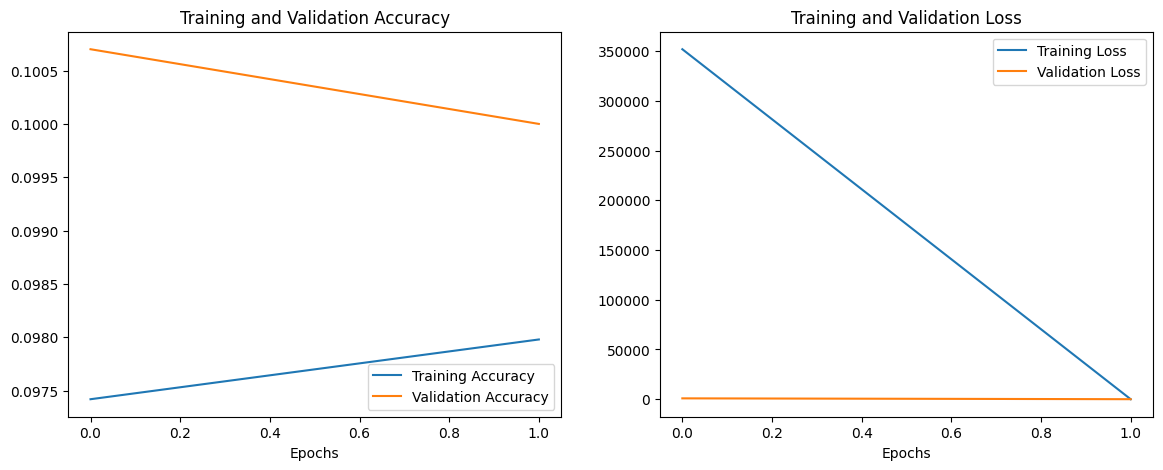

In [16]:
# plotting the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()
